In [1]:
from schnetpack.md.utils import HDF5Loader
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from schnetpack.md.utils import MDUnits
#from schnetpack import units as spk_units

%load_ext autoreload
%autoreload 2



In [2]:
data = HDF5Loader('md_logs/2022-05-16_mQEuhRFt/simulation_local_dipole_001.hdf5', load_properties=True, skip_initial=0)
#data = HDF5Loader('md_logs/2022-09-26_ZSZU3SV1/simulation_cluster_all_001_compressed.hdf5', load_properties=True, skip_initial=20000)

Shape: (200000, 1)


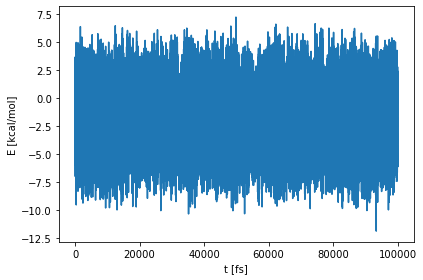

In [39]:
energies = data.get_property('energy')
print('Shape:', energies.shape)

# Get the time axis
time_axis = np.arange(data.entries)*data.time_step / spk.fs # in fs

# Plot the energies
plt.figure()
plt.plot(time_axis, energies)
plt.ylabel('E [kcal/mol]')
plt.xlabel('t [fs]')
plt.tight_layout()
plt.show()

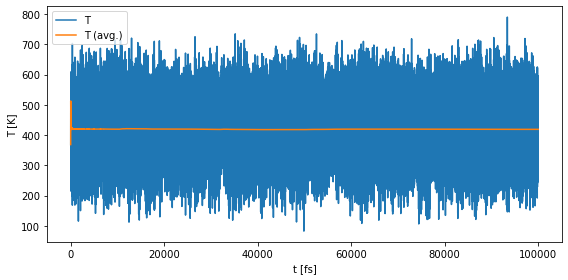

In [40]:
def plot_temperature(data):

    # Read the temperature
    temperature = data.get_temperature()

    # Compute the cumulative mean
    temperature_mean = np.cumsum(temperature) / (np.arange(data.entries)+1)

    # Get the time axis
    time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

    plt.figure(figsize=(8,4))
    plt.plot(time_axis, temperature, label='T')
    plt.plot(time_axis, temperature_mean, label='T (avg.)')
    plt.ylabel('T [K]')
    plt.xlabel('t [fs]')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_temperature(data)

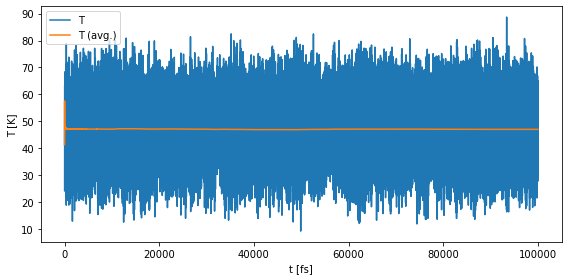

In [41]:
def plot_k_energy(data):

    # Read the k_energy
    k_energy = data.get_kinetic_energy()

    # Compute the cumulative mean
    k_energy_mean = np.cumsum(k_energy) / (np.arange(data.entries)+1)

    # Get the time axis
    time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

    plt.figure(figsize=(8,4))
    plt.plot(time_axis, k_energy, label='T')
    plt.plot(time_axis, k_energy_mean, label='T (avg.)')
    plt.ylabel('T [K]')
    plt.xlabel('t [fs]')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_k_energy(data)

std potential 2.432326
std kinetic 2.415245346422007
energy_unit 0.010364269574711572
kcal 2.5196637345688e+24
kJ 6.022140857000001e+23
ha 2625.4996387552483


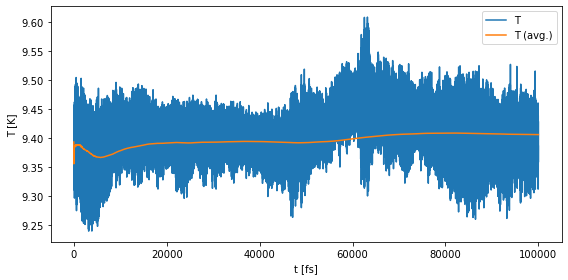

In [42]:
def plot_total_energy(data):

    # Read the k_energy
    k_energy = data.get_kinetic_energy() *  MDUnits.conversions['kj']/MDUnits.conversions['kcal']
    p_energy = data.get_property('energy').squeeze()
    print('std potential', np.std(p_energy))
    print('std kinetic', np.std(k_energy))
    print('energy_unit', MDUnits.energy_unit)
    print('kcal', MDUnits.conversions['kcal'])
    print('kJ', MDUnits.conversions['kj'])
    print('ha', MDUnits.conversions['ha'])
    total_energy = k_energy + p_energy

    # Compute the cumulative mean
    total_energy_mean = np.cumsum(total_energy) / (np.arange(data.entries)+1)

    # Get the time axis
    time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

    plt.figure(figsize=(8,4))
    plt.plot(time_axis, total_energy, label='T')
    plt.plot(time_axis, total_energy_mean, label='T (avg.)')
    plt.ylabel('T [K]')
    plt.xlabel('t [fs]')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_total_energy(data)

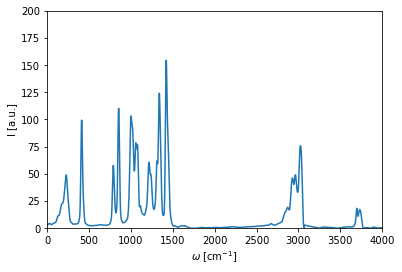

In [43]:
from schnetpack.md.utils.spectra import PowerSpectrum

spectrum = PowerSpectrum(data, resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,200)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.show()



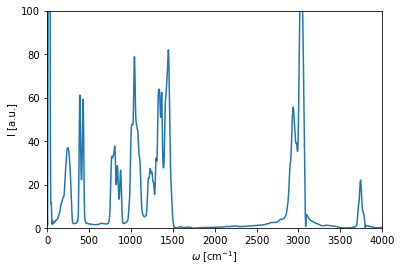

In [11]:
from schnetpack.md.utils.spectra import PowerSpectrum

spectrum = PowerSpectrum(data, resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,100)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.show()



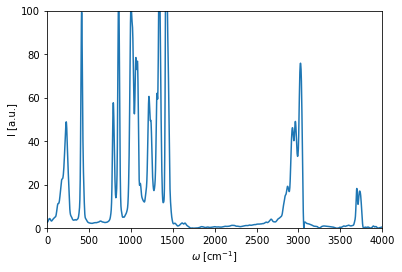

In [44]:
from schnetpack.md.utils.spectra import PowerSpectrum

spectrum = PowerSpectrum(data, resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,100)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')


#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_ethanol_vib_spectrum.svg')
plt.show()

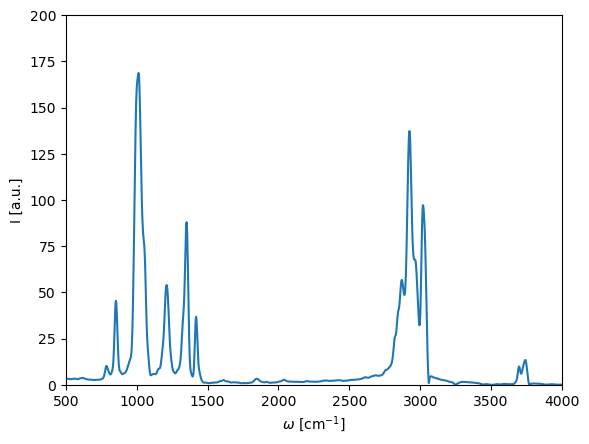

In [4]:
from schnetpack.md.utils.spectra import IRSpectrum

spectrum = IRSpectrum(data, dipole_moment_handle='dipole_moment', resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
frequencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(frequencies, intensities)
plt.xlim(500,4000)
plt.ylim(0,200)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_ethanol_IR_spectrum.svg')
plt.show()

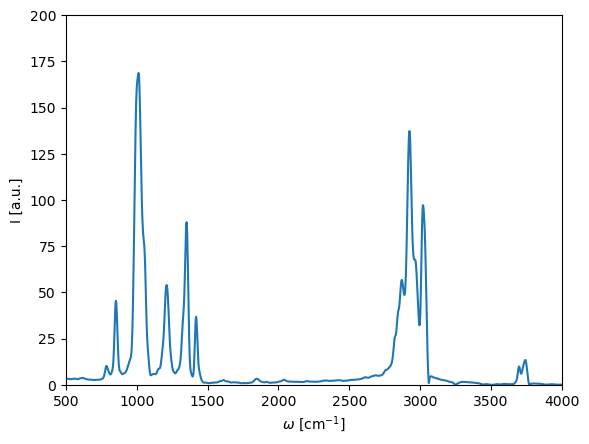

In [5]:
from schnetpack.md.utils.spectra import IRSpectrum
spectrum = IRSpectrum(data, dipole_moment_handle='dipole_moment', resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
frequencies, intensities = spectrum.get_spectrum()
plt.figure()
plt.plot(frequencies, intensities)
plt.xlim(500,4000)
plt.ylim(0,200)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/nat_manuscript/figures/ml_ethanol_IR_spectrum.svg')
plt.show()


{'title': 'ETHANOL', 'jcamp-dx': 4.24, 'data type': 'INFRARED SPECTRUM', 'class': 'COBLENTZ', 'origin': 'DOW CHEMICAL COMPANY', 'owner': 'COBLENTZ SOCIETY\nCollection (C) 2018 copyright by the U.S. Secretary of Commerce\non behalf of the United States of America. All rights reserved.', 'date': 1964, 'cas registry no': '64-17-5', 'molform': 'C2 H6 O', 'source reference': 'COBLENTZ NO. 8789', '$nist source': 'COBLENTZ', '$nist image': 'cob-r8789', 'spectrometer/data system': 'DOW KBr FOREPRISM-GRATING', 'instrument parameters': 'GRATING CHANGED AT 5.0, 7.5, 15.0 MICRON', 'state': 'GAS (30 mmHg, N2 ADDED, TOTAL PRESSURE 600 mmHg)', 'path length': '5 CM', 'sampling procedure': 'TRANSMISSION', 'resolution': 2, 'data processing': 'DIGITIZED BY NIST FROM HARD COPY (FROM TWO SEGMENTS)', 'xunits': '1/CM', 'yunits': 'TRANSMITTANCE', 'xfactor': 1.0, 'yfactor': 1, 'deltax': 0.9375, 'firstx': 461.563, 'lastx': 3807.5, 'firsty': 0.966, 'maxx': 3807.5, 'minx': 461.563, 'maxy': 1.024, 'miny': 0.142008

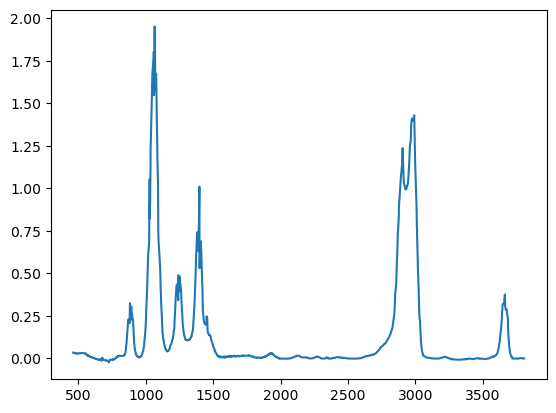

In [9]:
import jcamp

jcamp_data = jcamp.jcamp_readfile('datasets/ethanol_IR.jdx')
print(jcamp_data)
x = np.round(jcamp_data['x'])
y = jcamp_data['y']
y = - np.log(y)
plt.plot(x, y)
plt.show()

In [10]:
freqs = np.round(frequencies)
f_count = 0
f_match = []
x_count = 0
x_match = []

while f_count < len(freqs) and x_count < len(x):
    if freqs[f_count] == x[x_count]:
        f_match.append(f_count)
        x_match.append(x_count)
        f_count += 1
        x_count += 1
    elif freqs[f_count] < x[x_count]:
        f_count += 1
    else:
        x_count += 1

print(len(f_match))
print(len(x_match))
print(freqs[f_match])
print(x[x_match])

1644
1644
[ 462.  464.  466. ... 3803. 3805. 3807.]
[ 462.  464.  466. ... 3803. 3805. 3807.]


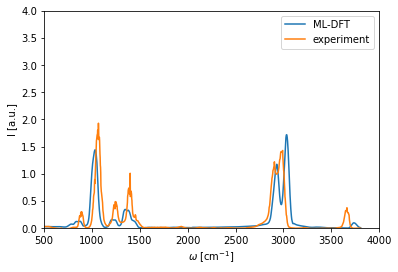

In [36]:
plt.figure()
#plt.plot(freqs[f_match]*0.95 + 100, intensities[f_match]/100)
plt.plot(freqs[f_match], intensities[f_match]/100, label='ML-DFT')
plt.plot(x[x_match], y[x_match], label='experiment')
plt.xlim(500, 4000)
plt.ylim(0,4)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.legend()
#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/nat_manuscript/figures/ml_ethanol_IR_spectrum_comp.pdf')
plt.show()

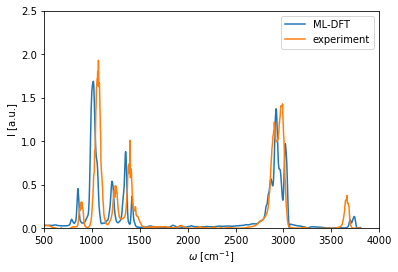

In [48]:
plt.figure()
#plt.plot(freqs[f_match]*0.95 + 100, intensities[f_match]/100)
plt.plot(freqs[f_match], intensities[f_match]/100, label='ML-DFT')
plt.plot(x[x_match], y[x_match], label='experiment')
plt.xlim(500, 4000)
plt.ylim(0,2.5)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.legend()
#plt.savefig('/home/mihail/Documents/workspace/equiv_dens/figures/ml_ethanol_IR_spectrum_comp.pdf')
plt.show()

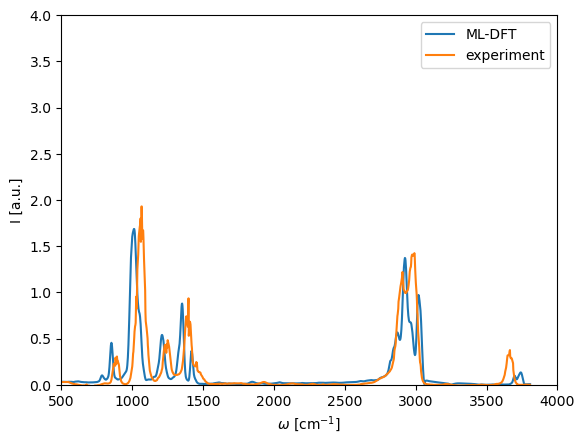

In [11]:
plt.figure()
#plt.plot(freqs[f_match]*0.95 + 100, intensities[f_match]/100)
plt.plot(freqs[f_match], intensities[f_match]/100, label='ML-DFT')
plt.plot(x[x_match], y[x_match], label='experiment')
plt.xlim(500, 4000)
plt.ylim(0,4)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.legend()
#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/nat_manuscript/figures/ml_ethanol_IR_spectrum_comp.pdf')
plt.show()

/home/mihail/miniconda3/envs/equiv_dens/lib/python3.10/site-packages/pyscf/prop/efg/rhf.py:45: UserWarning: Module EFG is under testing
  warnings.warn('Module EFG is under testing')
/home/mihail/miniconda3/envs/equiv_dens/lib/python3.10/site-packages/pyscf/prop/efg/dhf.py:30: UserWarning: Module EFG is under testing
  warnings.warn('Module EFG is under testing')
/home/mihail/miniconda3/envs/equiv_dens/lib/python3.10/site-packages/pyscf/prop/zfs/uhf.py:40: UserWarning: Module ZFS is under testing
  warnings.warn('Module ZFS is under testing')
/home/mihail/miniconda3/envs/equiv_dens/lib/python3.10/site-packages/pyscf/prop/gtensor/uhf.py:43: UserWarning: Module g-tensor is under testing
  warnings.warn('Module g-tensor is under testing')
/home/mihail/miniconda3/envs/equiv_dens/lib/python3.10/site-packages/pyscf/prop/gtensor/uks.py:41: UserWarning: Module g-tensor is under testing
  warnings.warn('Module g-tensor is under testing')
/home/mihail/miniconda3/envs/equiv_dens/lib/python3.10/si

atom_pos shape (1000, 9, 3)
atom_nums shape (9,)
min_en 274
converged SCF energy = -154.835235259002
------------------------------------------
 Mode      Frequency       Intensity      
   #         cm^-1          km/mol        
------------------------------------------

    0       398.8471i       103.7153
    1       114.9364i         0.8845
    2       348.8369          2.8816
    3       725.6793          2.2505
    4       800.2111          1.7722
    5       955.7060         14.9528
    6      1070.5626         73.0337
    7      1150.9907         84.5772
    8      1237.3522          2.4794
    9      1304.1638          3.5580
   10      1318.8274          3.0908
   11      1343.1787         32.7590
   12      1388.5412          5.8938
   13      1409.4266          9.8127
   14      1433.1960          0.6880
   15      2891.8536         84.7974
   16      3002.6832         23.2776
   17      3030.0667         34.3988
   18      3075.5566         22.8650
   19      3206.5542   

/tmp/ipykernel_785197/151205187.py:42: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


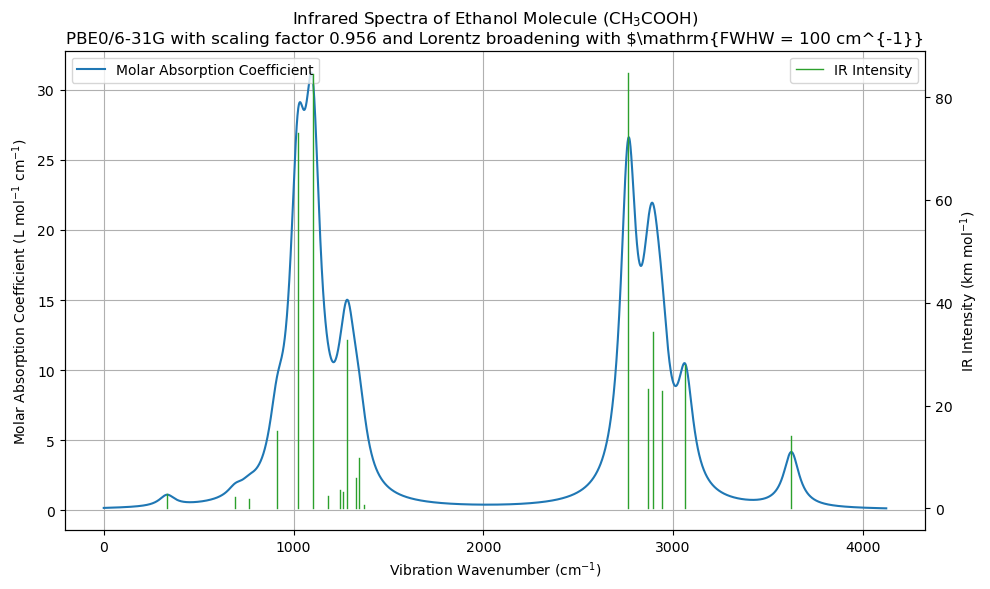

In [12]:
# load data
import ase
import ase.io
import pyscf
import os
from pyscf import gto, dft, df, lib
from pyscf.scf import hf
import scipy
import equiv_dens.utils.base as utils
from pyscf.prop import infrared
hf.MUTE_CHKFILE = True

basis = 'ccpvdz'
for dataset in ['train']:
    load_path = 'datasets/ethanol_dft_' + dataset + '.npy'
    data = np.load(load_path, allow_pickle=True).item()
    results = []
    min_en = np.argmin(data['energy'])
    print('atom_pos shape', data['positions'].shape)
    print('atom_nums shape', data['atom_numbers'].shape)
    print('min_en', min_en)
    start = time.time()
    pos = data['positions'][min_en]
    atom_nums = data['atom_numbers'] 
    atom = []
    for j in range(len(atom_nums)):
        atom.append((atom_nums[j], pos[j, :])) 
    mol = gto.M(atom=atom, basis=basis)
    #print(mol.pack())
    mf = dft.RKS(mol)
    mf.chkfile=False
    mf.xc = 'pbe'
    #mf.max_cycle = 1000
    mf.kernel()
    mf_ir = infrared.rks.Infrared(mf).run()
    mf_ir.summary()
    
    fig, ax, ax2 = mf_ir.plot_ir(w=100, scale=0.956)
    ax.set_title(r"Infrared Spectra of Ethanol Molecule ($\mathrm{CH_3COOH}$)" "\n"
                 r"PBE0/6-31G with scaling factor 0.956 and Lorentz broadening with $\mathrm{FWHW = 100 cm^{-1}}")
    fig.tight_layout()
    fig.show()

In [70]:
mf_freq = mf_ir.vib_dict["freq_wavenumber"].real
mf_int = mf_ir.ir_inten

freq_diff = mf_freq[:, None] - freqs[f_match][None, :]

mf_match = np.where(np.abs(freq_diff) <= 1)[1]
print(freq_diff)
print(np.where(np.abs(freq_diff) <= 1))
print('freqs', mf_freq)
print('freqs match', freqs[f_match])
print('intens', mf_int)

[[ -462.          -464.          -466.         ... -3803.
  -3805.         -3807.        ]
 [ -462.          -464.          -466.         ... -3803.
  -3805.         -3807.        ]
 [ -113.1631475   -115.1631475   -117.1631475  ... -3454.1631475
  -3456.1631475  -3458.1631475 ]
 ...
 [ 2613.55655758  2611.55655758  2609.55655758 ...  -727.44344242
   -729.44344242  -731.44344242]
 [ 2744.55420217  2742.55420217  2740.55420217 ...  -596.44579783
   -598.44579783  -600.44579783]
 [ 3328.43717628  3326.43717628  3324.43717628 ...   -12.56282372
    -14.56282372   -16.56282372]]
(array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20]), array([ 129,  166,  242,  299,  338,  381,  414,  421,  433,  455,  465,
        477, 1193, 1248, 1262, 1284, 1348, 1635]))
freqs [   0.            0.          348.8368525   725.67930345  800.21114941
  955.70600556 1070.56259343 1150.99065931 1237.35220932 1304.16379072
 1318.82743635 1343.17865691 1388.54121014 1409.42662893

mf freq [   0.            0.          348.8368525   725.67930345  800.21114941
  955.70600556 1070.56259343 1150.99065931 1237.35220932 1304.16379072
 1318.82743635 1343.17865691 1388.54121014 1409.42662893 1433.19603429
 2891.85362445 3002.6831546  3030.06669392 3075.55655758 3206.55420217
 3790.43717628]


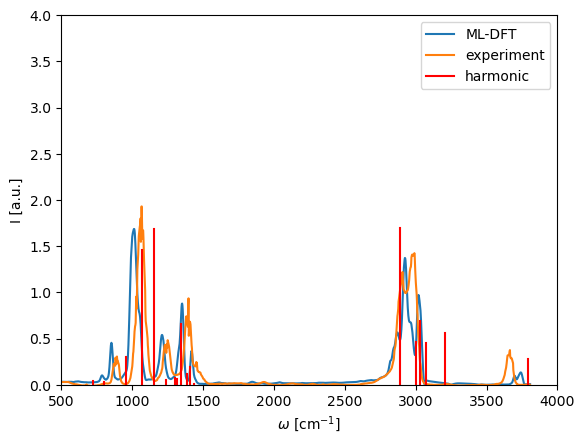

In [73]:
fig = plt.figure()
ax = fig.add_subplot(111)
#plt.plot(freqs[f_match]*0.95 + 100, intensities[f_match]/100)
ax.plot(freqs[f_match], intensities[f_match]/100, label='ML-DFT')
ax.plot(x[x_match], y[x_match], label='experiment')
for i in range(len(mf_freq)):
    if i == 0:
        ax.plot([mf_freq[i], mf_freq[i]], [0, mf_int[i]/50], label='harmonic', color='r')
    else:
        ax.plot([mf_freq[i], mf_freq[i]], [0, mf_int[i]/50], color='r')
plt.xlim(500, 4000)
plt.ylim(0,4)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
print('mf freq', mf_freq)

plt.legend()
#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/nat_manuscript/figures/ml_ethanol_IR_spectrum_comp.pdf')
plt.show()

In [18]:
from schnetpack.md.utils.spectra import fft_autocorrelation
dpm = data.get_property('dipole_moment')
print(dpm.shape)
autocorr = np.zeros((3, dpm.shape[0] - 1))
for i in range(dpm.shape[1]):
    print('i', i)
    autocorr[i] = fft_autocorrelation(dpm[:, i], dpm.shape[0] - 2)

print(autocorr.shape)

(200000, 3)
i 0
i 1
i 2
(3, 199999)


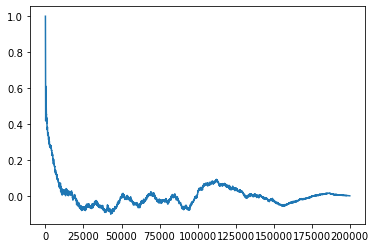

In [19]:
import matplotlib.pyplot as plt

plt.plot(np.mean(autocorr, axis=0))

#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/autocorrelation.svg')
plt.show()

[[ -7.648527    8.224964    6.5621133]
 [-11.796831   12.331962    6.8140025]
 [-13.459861    7.822513   10.413288 ]
 ...
 [ -3.651142    0.9157657 -17.133713 ]
 [ -3.781229   -4.9688816  -6.9968696]
 [ -0.7128417   1.5041827 -10.929107 ]]
i 0
i 1
i 2
(3, 199998)


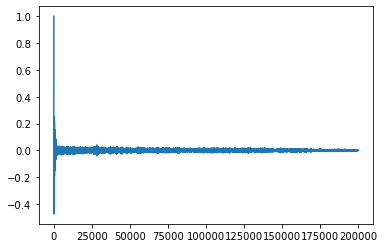

In [20]:
h = 0.5 / 1000

diff = np.diff(dpm, axis=0)
diff = diff/h
print(diff)

autocorr = np.zeros((3, diff.shape[0] - 1))
for i in range(diff.shape[1]):
    print('i', i)
    autocorr[i] = fft_autocorrelation(diff[:, i], diff.shape[0] - 2)
    
print(autocorr.shape)
plt.plot(np.mean(autocorr, axis=0))

#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/diff_autocorrelation.svg')
plt.show()